# 🧬 Leukemia Classification Using Gene Expression Data

![Leukemia Image](https://my.clevelandclinic.org/-/scassets/images/org/health/articles/4365-leukemia)

## 📌 Project Overview
This project aims to classify different types of leukemia using gene expression data from the GSE13159 dataset. The dataset contains 2,096 bone marrow samples from patients with various leukemia subtypes, with expression measurements for 54,675 genes.

## 📊 Dataset Information
- **Source**: GEO (Gene Expression Omnibus) - GSE13159
- **Samples**: 2,096 bone marrow samples
- **Genes**: 54,675 probe sets (Affymetrix Human Genome U133 Plus 2.0 Array)
- **Leukemia Types**: 18 distinct subtypes including CLL, AML, ALL, MDS, CML, and others

## 🎯 Objectives
1. Load and preprocess gene expression data  
2. Extract leukemia type labels from metadata  
3. Clean and normalize the data  
4. Train multiple machine learning models  
5. Achieve high accuracy in leukemia subtype classification  

## 🏆 Best Model Result
**Logistic Regression** achieved **89.29% accuracy** in classifying 18 different leukemia types.

In [1]:
#Import Important Libraries
import pandas as pd
import numpy as np
import os
import gzip
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

##  Data Loading - Gene Expression

In [2]:
file_path = r"C:\Users\Lenovo\OneDrive\Desktop\GEO_project\GSE13159_series_matrix.txt"

df = pd.read_csv(file_path, sep="\t", comment="!", header=0)

print(f"Data loaded: {df.shape[0]} genes × {df.shape[1]} samples")
print(f"First 5 columns: {df.columns[:5].tolist()}")


Data loaded: 54675 genes × 2097 samples
First 5 columns: ['ID_REF', 'GSM329407', 'GSM329408', 'GSM329409', 'GSM329410']


In [3]:
df.head()

,ID_REF,GSM329407,GSM329408,GSM329409,GSM329410,GSM329411,GSM329412,GSM329413,GSM329414,GSM329415,...,GSM331723,GSM331724,GSM331725,GSM331726,GSM331727,GSM331728,GSM331729,GSM331730,GSM331731,GSM331732
0,1007_s_at,0.361346,0.396426,0.419317,0.424651,0.287776,0.497901,0.258365,0.341919,0.327573,...,0.319327,0.316831,0.313745,0.206255,0.283618,0.303911,0.275196,0.192931,0.201153,0.338141
1,1053_at,0.450274,0.559457,0.436466,0.512677,0.194097,0.491377,0.371146,0.534267,0.443831,...,0.445019,0.441793,0.432226,0.497191,0.428511,0.442613,0.421250,0.464649,0.424169,0.400601
2,117_at,0.431178,0.402577,0.306609,0.217119,0.355157,0.373115,0.447995,0.352907,0.453844,...,0.302065,0.343136,0.468016,0.294332,0.346195,0.307146,0.275079,0.344369,0.316504,0.275581
3,121_at,0.405517,0.437968,0.479352,0.484471,0.453368,0.483568,0.405649,0.422899,0.449049,...,0.429109,0.411652,0.405047,0.432783,0.446961,0.495226,0.453725,0.397760,0.480837,0.451893
4,1255_g_at,0.160812,0.089130,0.117863,0.222672,0.180248,0.016069,0.156327,0.159536,0.177681,...,0.091426,0.188176,0.122430,0.099128,0.099705,0.229050,0.069293,0.081494,0.155701,0.044505


## Data Preparation - Set Index and Transpose

In [4]:
df = df.set_index("ID_REF")
print(f"After setting index: {df.shape[0]} genes × {df.shape[1]} samples")

df_T = df.T
print(f"After transpose: {df_T.shape[0]} samples × {df_T.shape[1]} genes")

df_T.index = df_T.index.str.strip('"')
print(f"First 5 samples: {df_T.index[:5].tolist()}")

After setting index: 54675 genes × 2096 samples
After transpose: 2096 samples × 54675 genes
First 5 samples: ['GSM329407', 'GSM329408', 'GSM329409', 'GSM329410', 'GSM329411']


In [5]:
df.head()

,GSM329407,GSM329408,GSM329409,GSM329410,GSM329411,GSM329412,GSM329413,GSM329414,GSM329415,GSM329416,...,GSM331723,GSM331724,GSM331725,GSM331726,GSM331727,GSM331728,GSM331729,GSM331730,GSM331731,GSM331732
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,0.361346,0.396426,0.419317,0.424651,0.287776,0.497901,0.258365,0.341919,0.327573,0.351202,...,0.319327,0.316831,0.313745,0.206255,0.283618,0.303911,0.275196,0.192931,0.201153,0.338141
1053_at,0.450274,0.559457,0.436466,0.512677,0.194097,0.491377,0.371146,0.534267,0.443831,0.436740,...,0.445019,0.441793,0.432226,0.497191,0.428511,0.442613,0.421250,0.464649,0.424169,0.400601
117_at,0.431178,0.402577,0.306609,0.217119,0.355157,0.373115,0.447995,0.352907,0.453844,0.398450,...,0.302065,0.343136,0.468016,0.294332,0.346195,0.307146,0.275079,0.344369,0.316504,0.275581
121_at,0.405517,0.437968,0.479352,0.484471,0.453368,0.483568,0.405649,0.422899,0.449049,0.429771,...,0.429109,0.411652,0.405047,0.432783,0.446961,0.495226,0.453725,0.397760,0.480837,0.451893
1255_g_at,0.160812,0.089130,0.117863,0.222672,0.180248,0.016069,0.156327,0.159536,0.177681,0.043646,...,0.091426,0.188176,0.122430,0.099128,0.099705,0.229050,0.069293,0.081494,0.155701,0.044505


## Extract Labels from Metadata 

In [6]:
print("Extracting leukemia labels from metadata...")

sample_labels = {}

with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
    sample_names = []
    found_samples = False
    
    for line in f:
        line = line.strip()
        
        if line.startswith("!Sample_geo_accession"):
            parts = line.split("\t")
            sample_names = [name.strip('"') for name in parts[1:]]
            found_samples = True
            print(f"Found {len(sample_names)} samples")
            
        elif line.startswith("!Sample_characteristics_ch1") and found_samples:
            parts = line.split("\t")
            if "leukemia class" in line:
                for i, sample in enumerate(sample_names):
                    if i + 1 < len(parts):
                        char_value = parts[i + 1].strip('"')
                        if "leukemia class:" in char_value:
                            label = char_value.split(":", 1)[1].strip()
                            sample_labels[sample] = label
        
        elif line.startswith("!series_matrix_table_begin"):
            print("Labels extraction completed")
            break

print(f"Extracted {len(sample_labels)} labels")

Extracting leukemia labels from metadata...
Found 2096 samples
Labels extraction completed
Extracted 2096 labels


## Labels Distribution

In [7]:
label_counts = pd.Series(sample_labels).value_counts()
print("Leukemia types distribution:")
print("="*50)
for label, count in label_counts.items():
    print(f"{label}: {count} samples")
print("="*50)
print(f"Total: {len(sample_labels)} samples")

Leukemia types distribution:
CLL: 448 samples
AML with normal karyotype + other abnormalities: 351 samples
c-ALL/Pre-B-ALL without t(9;22): 237 samples
MDS: 206 samples
T-ALL: 174 samples
c-ALL/Pre-B-ALL with t(9;22): 122 samples
CML: 76 samples
Non-leukemia and healthy bone marrow: 74 samples
Pro-B-ALL with t(11q23)/MLL: 70 samples
ALL with t(12;21): 58 samples
AML complex aberrant karyotype: 48 samples
ALL with hyperdiploid karyotype: 40 samples
AML with t(8;21): 40 samples
AML with t(11q23)/MLL: 38 samples
AML with t(15;17): 37 samples
ALL with t(1;19): 36 samples
AML with inv(16)/t(16;16): 28 samples
mature B-ALL with t(8;14): 13 samples
Total: 2096 samples


## Data Cleaning - Handle Missing Values

In [8]:
common_samples = df_T.index.intersection(sample_labels.keys())
print(f"Common samples: {len(common_samples)} out of {len(df_T)}")

Common samples: 2096 out of 2096


In [9]:
X = df_T.loc[common_samples]
y = pd.Series({sample: sample_labels[sample] for sample in common_samples})

In [10]:
missing_threshold = 0.5
missing_ratio = X.isnull().mean()
genes_to_keep = missing_ratio[missing_ratio < missing_threshold].index
X_clean = X[genes_to_keep]
print(f"After removing genes with {missing_threshold*100}% missing values: {X_clean.shape[1]} genes")

After removing genes with 50.0% missing values: 54630 genes


In [11]:
if X_clean.shape[1] > 5000:
    print(f"Reducing to first 5000 genes for memory efficiency")
    X_clean = X_clean.iloc[:, :5000]
    print(f"Reduced to {X_clean.shape[1]} genes")

X_filled = X_clean.fillna(X_clean.mean())
print("Missing values filled with column means")

Reducing to first 5000 genes for memory efficiency
Reduced to 5000 genes
Missing values filled with column means


## Data Normalization

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)
X_scaled = pd.DataFrame(X_scaled, index=X_filled.index, columns=X_filled.columns)

print(f"Data normalized (mean ≈ 0, std ≈ 1)")
print(f"Final data shape: {X_scaled.shape[0]} samples × {X_scaled.shape[1]} genes")

Data normalized (mean ≈ 0, std ≈ 1)
Final data shape: 2096 samples × 5000 genes


## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of genes: {X_train.shape[1]}")

Training set: 1676 samples
Test set: 420 samples
Number of genes: 5000


## PCA Visualization

In [14]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(X_scaled)

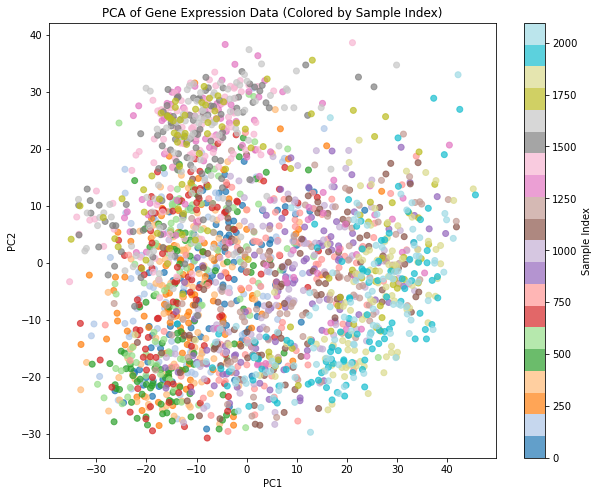

In [15]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=range(len(y)), cmap='tab20', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Gene Expression Data (Colored by Sample Index)")
plt.colorbar(scatter, label='Sample Index')
plt.show()

In [16]:
print(f"Explained variance ratio PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Explained variance ratio PC2: {pca.explained_variance_ratio_[1]:.2%}")

Explained variance ratio PC1: 5.82%
Explained variance ratio PC2: 4.81%


In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

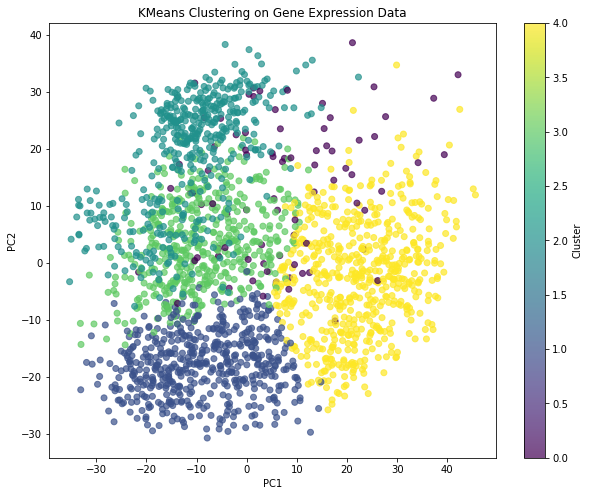

In [18]:
plt.figure(figsize=(10, 8))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering on Gene Expression Data")
plt.colorbar(label='Cluster')
plt.show()

## Model Comparison

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

In [20]:
results = {}
training_times = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    training_times[name] = training_time
    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"{name}: Accuracy = {accuracy:.2%} (Time: {training_time:.2f}s)")


Training Logistic Regression...
Logistic Regression: Accuracy = 89.29% (Time: 19.41s)

Training KNN (k=5)...
KNN (k=5): Accuracy = 71.90% (Time: 0.08s)

Training SVM...
SVM: Accuracy = 74.76% (Time: 15.79s)

Training Random Forest...
Random Forest: Accuracy = 75.00% (Time: 1.34s)


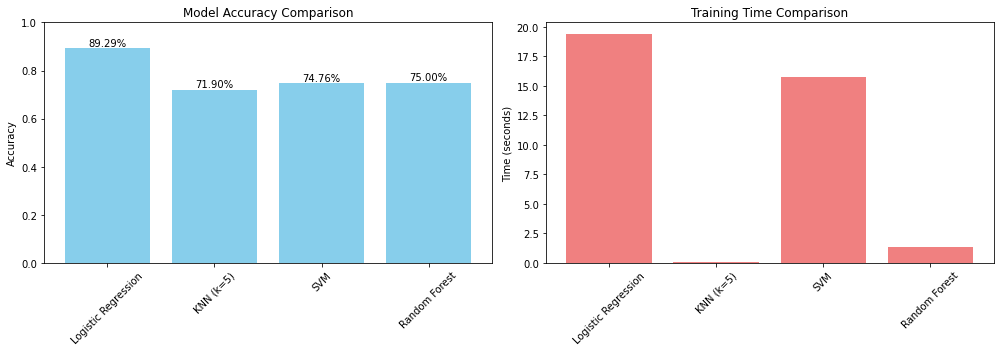

In [21]:
#Model Comparison Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(results.keys(), results.values(), color='skyblue')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
for i, (name, acc) in enumerate(results.items()):
    ax1.text(i, acc + 0.01, f'{acc:.2%}', ha='center', fontsize=10)

ax2.bar(training_times.keys(), training_times.values(), color='lightcoral')
ax2.set_title('Training Time Comparison')
ax2.set_ylabel('Time (seconds)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [22]:
best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} with {results[best_model]:.2%} accuracy")


Best Model: Logistic Regression with 89.29% accuracy


In [23]:
#Detailed Analysis of Best Model (Logistic Regression)
lr_best = LogisticRegression(max_iter=2000, random_state=42, C=1.0, solver='lbfgs', multi_class='multinomial')
lr_best.fit(X_train, y_train)

y_pred = lr_best.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 89.29%

Detailed Classification Report:
                                                 precision    recall  f1-score   support

                ALL with hyperdiploid karyotype       0.83      0.62      0.71         8
                              ALL with t(12;21)       0.92      0.92      0.92        12
                               ALL with t(1;19)       1.00      0.86      0.92         7
                 AML complex aberrant karyotype       1.00      0.30      0.46        10
                      AML with inv(16)/t(16;16)       1.00      0.83      0.91         6
AML with normal karyotype + other abnormalities       0.79      0.89      0.84        70
                          AML with t(11q23)/MLL       1.00      0.38      0.55         8
                              AML with t(15;17)       1.00      0.86      0.92         7
                               AML with t(8;21)       1.00      0.88      0.93         8
                                            CLL       0.99

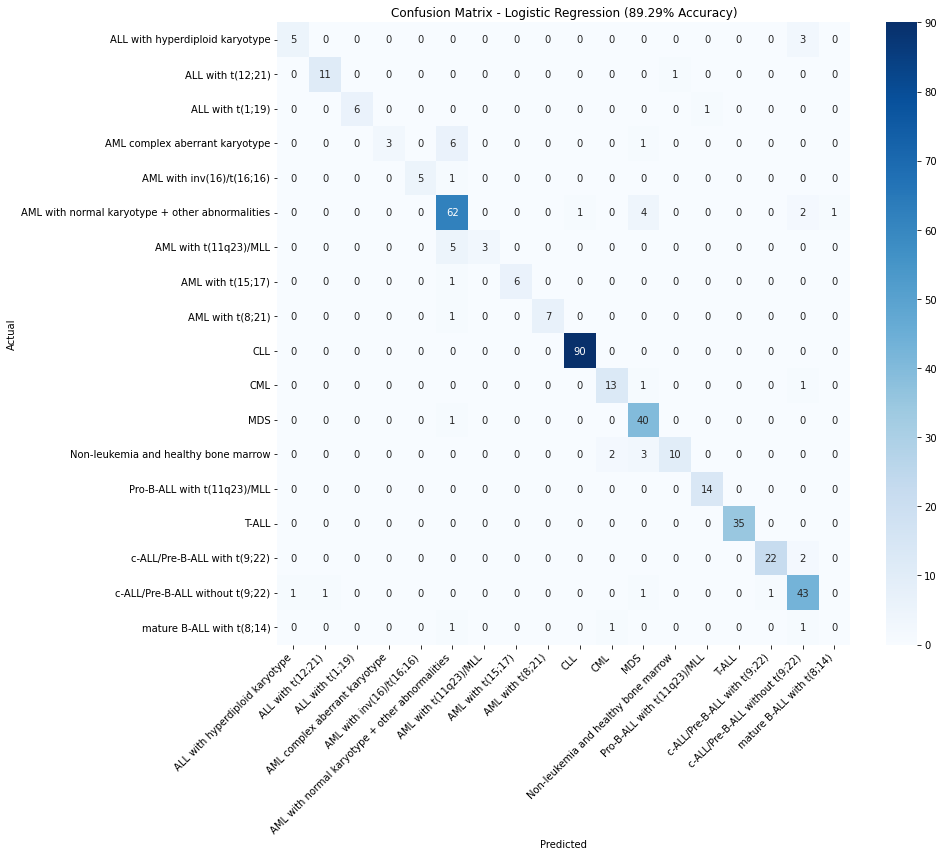

In [24]:
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lr_best.classes_, 
            yticklabels=lr_best.classes_)
plt.title(f'Confusion Matrix - Logistic Regression ({accuracy:.2%} Accuracy)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Importance (Gene Weights)

In [25]:
feature_importance_lr = pd.DataFrame({
    'gene': X_scaled.columns,
    'weight': np.mean(np.abs(lr_best.coef_), axis=0)  # ← التغيير هنا
})
feature_importance_lr = feature_importance_lr.sort_values('weight', ascending=False)

In [26]:
print("\nTop 20 Most Important Genes (Logistic Regression):")
print("="*60)
for i, row in feature_importance_lr.head(20).iterrows():
    print(f"{i+1:2d}. {row['gene']:20} → Weight: {row['weight']:.4f}")


Top 20 Most Important Genes (Logistic Regression):
289. 1552665_at           → Weight: 0.0209
4805. 1559477_s_at         → Weight: 0.0208
4402. 1558770_a_at         → Weight: 0.0193
4616. 1559131_a_at         → Weight: 0.0186
2980. 1556395_at           → Weight: 0.0179
2428. 1555579_s_at         → Weight: 0.0177
2743. 1556033_at           → Weight: 0.0175
3533. 1557261_at           → Weight: 0.0174
2744. 1556034_s_at         → Weight: 0.0173
853. 1553436_at           → Weight: 0.0173
772. 1553328_a_at         → Weight: 0.0172
4108. 1558217_at           → Weight: 0.0170
3093. 1556579_s_at         → Weight: 0.0168
2793. 1556114_a_at         → Weight: 0.0165
1123. 1553808_a_at         → Weight: 0.0164
3651. 1557450_s_at         → Weight: 0.0164
324. 1552715_a_at         → Weight: 0.0163
4687. 1559265_at           → Weight: 0.0163
260. 1552623_at           → Weight: 0.0163
4069. 1558139_at           → Weight: 0.0160


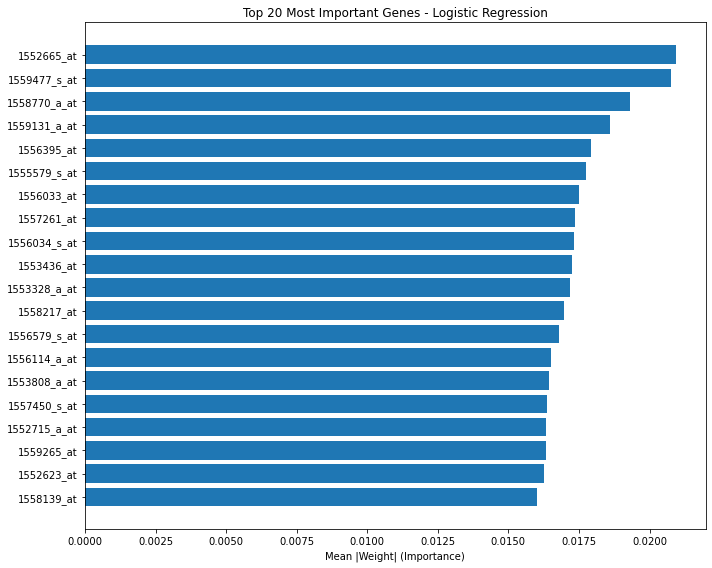

In [27]:
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_lr.head(20)['weight'][::-1])
plt.yticks(range(20), feature_importance_lr.head(20)['gene'][::-1])
plt.xlabel('Mean |Weight| (Importance)')
plt.title('Top 20 Most Important Genes - Logistic Regression')
plt.tight_layout()
plt.show()

## Learning curve 

Learning Curve Analysis:


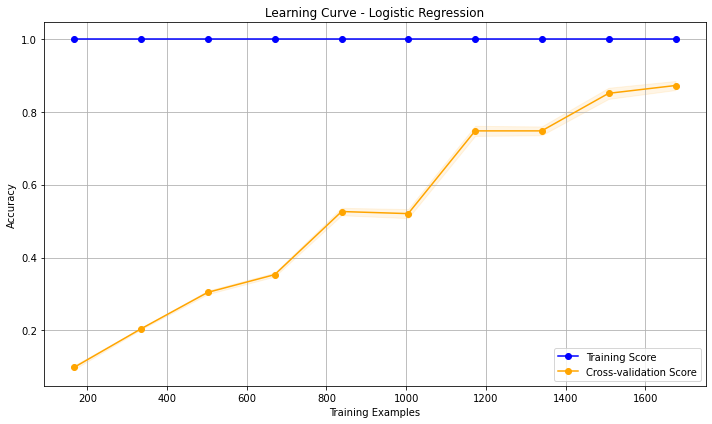

In [28]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation Score')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Learning Curve Analysis:")
plot_learning_curve(lr_best, X_scaled, y, 'Learning Curve - Logistic Regression')

## Hyperparameter Tuning (Grid Search)

In [29]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['lbfgs'],
    'max_iter': [1000, 2000]
}

In [30]:
lr_grid = LogisticRegression(random_state=42, multi_class='multinomial')
grid_search = GridSearchCV(lr_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(multi_class='multinomial',
                                          random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'max_iter': [1000, 2000],
                         'solver': ['lbfgs']},
             scoring='accuracy', verbose=1)

In [31]:
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.2%}")


Best parameters: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
Best cross-validation accuracy: 84.85%


In [32]:
lr_optimized = grid_search.best_estimator_
y_pred_opt = lr_optimized.predict(X_test)
accuracy_opt = accuracy_score(y_test, y_pred_opt)

print(f"Test set accuracy: {accuracy_opt:.2%}")

Test set accuracy: 89.05%


In [33]:
# poor performance analysis 
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

In [34]:
poor_performance = report_df[report_df['f1-score'] < 0.7].index

In [35]:
print("Classes Needing Improvement (F1-score < 0.7):")
print("="*50)
for cls in poor_performance:
    if cls not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"{cls}: F1 = {report_df.loc[cls, 'f1-score']:.2%}")

Classes Needing Improvement (F1-score < 0.7):
AML complex aberrant karyotype: F1 = 46.15%
AML with t(11q23)/MLL: F1 = 54.55%
mature B-ALL with t(8;14): F1 = 0.00%


## Save model

In [36]:
print("Saving trained model...")

joblib.dump(lr_best, 'leukemia_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(X_scaled.columns, 'gene_names.joblib')

with open('leukemia_model.pkl', 'wb') as f:
    pickle.dump(lr_best, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved successfully!")
print("  - leukemia_model.joblib (model)")
print("  - scaler.joblib (scaler)")
print("  - gene_names.joblib (gene names)")

Saving trained model...
Model saved successfully!
  - leukemia_model.joblib (model)
  - scaler.joblib (scaler)
  - gene_names.joblib (gene names)


## Prediction Function

In [37]:
def predict_leukemia_type(model, scaler, new_sample, gene_names):
    """
    Predict leukemia type for a new sample
    
    Parameters:
    - model: trained model
    - scaler: fitted StandardScaler
    - new_sample: array of gene expression values
    - gene_names: list of gene names
    
    Returns:
    - prediction: predicted leukemia type
    - probabilities: probability scores for each class
    """
    new_sample_scaled = scaler.transform(new_sample.reshape(1, -1))
    prediction = model.predict(new_sample_scaled)
    probabilities = model.predict_proba(new_sample_scaled)
    
    print(f"\nPredicted Leukemia Type: {prediction[0]}")
    print("\nTop 5 Probabilities:")
    
    prob_df = pd.DataFrame({
        'Type': model.classes_,
        'Probability': probabilities[0]
    }).sort_values('Probability', ascending=False)
    
    for i, row in prob_df.head(5).iterrows():
        print(f"  {row['Type']}: {row['Probability']:.2%}")
    
    return prediction[0], probabilities[0]

print("Prediction function ready")
print("Example usage: predict_leukemia_type(lr_best, scaler, new_patient_data, X_scaled.columns)")

Prediction function ready
Example usage: predict_leukemia_type(lr_best, scaler, new_patient_data, X_scaled.columns)
